In [22]:
# Library imports
import os
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from torchvision.utils import make_grid
from tqdm import tqdm

In [23]:
# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [24]:
# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"PyTorch version: {torch.__version__}")

Using device: cuda
PyTorch version: 2.7.1+cu128


In [25]:
# Define transforms
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and load training data
train_dataset = datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

# Download and load test data
test_dataset = datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

# Split training data into train/validation (50,000 / 10,000)
train_size = 50000
val_size = 10000
train_dataset, val_dataset = random_split(train_dataset, [train_size, val_size])

# Create DataLoaders
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.dataset.classes)}")
print(f"Classes: {train_dataset.dataset.classes}")

Training samples: 50000
Validation samples: 10000
Test samples: 10000
Number of classes: 10
Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']


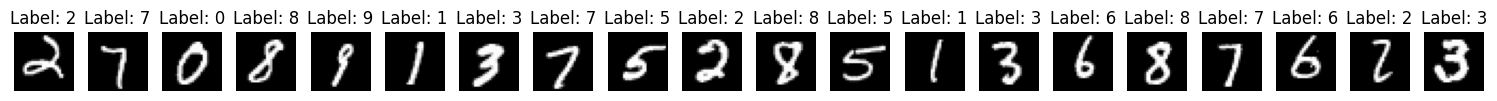

In [26]:
# Visualize some training samples
def show_samples(loader, num_samples=8):
    images, labels = next(iter(loader))
    images = images[:num_samples]
    labels = labels[:num_samples]
    
    mean, std = 0.1307, 0.3081
    images = images * std + mean
    
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))
    for i, (img, label) in enumerate(zip(images, labels)):
        axes[i].imshow(img.squeeze(), cmap='gray')
        axes[i].set_title(f'Label: {label.item()}')
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

show_samples(train_loader, 20)

In [27]:
class MLP(nn.Module):
    def __init__(self, input_size=784, hidden_sizes=[256, 128], num_classes=10, activation='relu', dropout=0.2):
        super().__init__()
        
        activations = {
            'relu': nn.ReLU(),
            'leaky_relu': nn.LeakyReLU(0.01),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
            'sigmoid': nn.Sigmoid(),
        }
        
        if activation not in activations:
            raise ValueError(f"Unknown activation: {activation}. Choose from {list(activations.keys())}")
        
        self.activation_fn = activations[activation]
        self.dropout = nn.Dropout(dropout)
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(self.activation_fn)
            layers.append(self.dropout)
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        x = x.view(x.size(0), -1)
        return self.network(x)
    
    def get_num_parameters(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

# Test the model
model = MLP(hidden_sizes=[256, 128], activation='relu', dropout=0.2)
print(f"Model architecture:\n{model}")
print(f"\nTotal trainable parameters: {model.get_num_parameters():,}")

Model architecture:
MLP(
  (activation_fn): ReLU()
  (dropout): Dropout(p=0.2, inplace=False)
  (network): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)

Total trainable parameters: 235,146


In [28]:
def create_model_and_optimizer(hidden_sizes=[256, 128], activation='relu', dropout=0.2, lr=1e-3, weight_decay=1e-4):
    model = MLP(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout
    ).to(device)
    
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3
    )
    
    return model, criterion, optimizer, scheduler

model, criterion, optimizer, scheduler = create_model_and_optimizer()
print(f"Model parameters: {model.get_num_parameters():,}")

Model parameters: 235,146


In [29]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """Train for one epoch."""
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in tqdm(loader):
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = 100. * correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)

In [30]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, device, num_epochs=20, patience=7):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': []
    }
    
    best_val_loss = float('inf')
    best_model_state = None
    epochs_no_improve = 0
    
    for epoch in range(1, num_epochs + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)
        
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)
        
        print(f"Epoch:{epoch:>5} | Train Loss:{train_loss:>10.4f} | Train Acc:{train_acc:>9.2f} | Val Loss:{val_loss:>9.4f} | Val Acc:{val_acc:>8.2f} | Current LR:{current_lr:>8.2e}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = model.state_dict().copy()
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping triggered after {epoch} epochs")
            break
    
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    return history

print("Starting training...\n")
history = train_model(
    model, train_loader, val_loader,
    criterion, optimizer, scheduler,
    device, num_epochs=20, patience=7
)

Starting training...



100%|██████████| 782/782 [00:07<00:00, 100.58it/s]


Epoch:    1 | Train Loss:    0.2941 | Train Acc:    91.05 | Val Loss:   0.1569 | Val Acc:   95.40 | Current LR:1.00e-03


100%|██████████| 782/782 [00:07<00:00, 98.11it/s] 


Epoch:    2 | Train Loss:    0.1346 | Train Acc:    95.85 | Val Loss:   0.1306 | Val Acc:   96.03 | Current LR:1.00e-03


...

Epoch:   18 | Train Loss:    0.0162 | Train Acc:    99.45 | Val Loss:   0.0739 | Val Acc:   98.32 | Current LR:2.50e-04


100%|██████████| 782/782 [00:07<00:00, 98.31it/s] 


Epoch:   19 | Train Loss:    0.0137 | Train Acc:    99.56 | Val Loss:   0.0739 | Val Acc:   98.15 | Current LR:2.50e-04


100%|██████████| 782/782 [00:07<00:00, 98.26it/s] 


Epoch:   20 | Train Loss:    0.0129 | Train Acc:    99.58 | Val Loss:   0.0805 | Val Acc:   98.19 | Current LR:2.50e-04

Early stopping triggered after 20 epochs


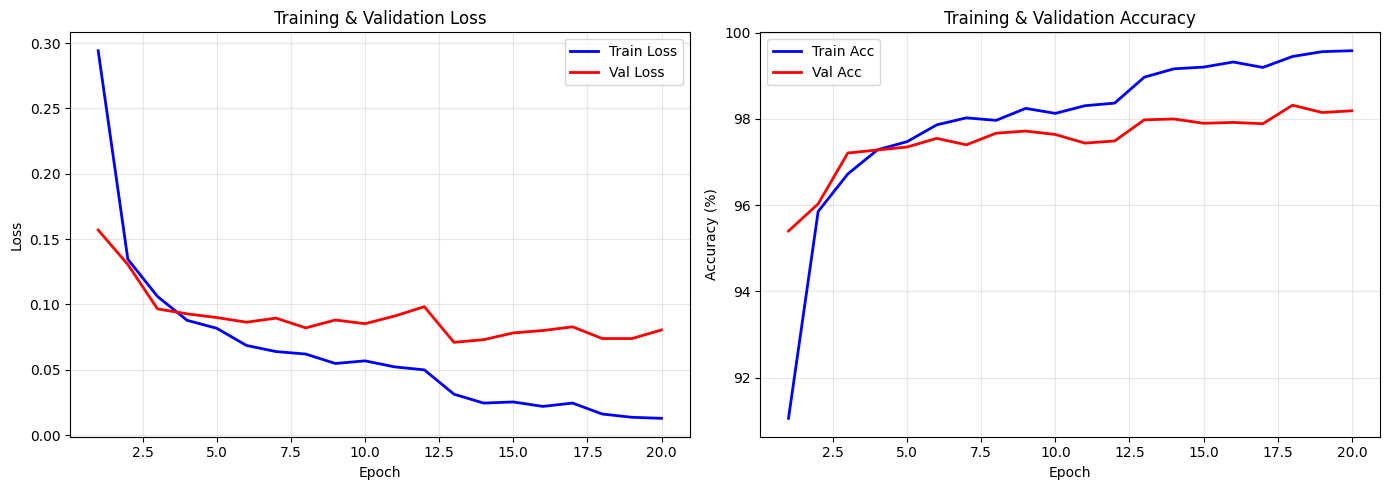

In [31]:
def plot_training_curves(history):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss curves
    axes[0].plot(epochs, history['train_loss'], 'b-', label='Train Loss', linewidth=2)
    axes[0].plot(epochs, history['val_loss'], 'r-', label='Val Loss', linewidth=2)
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training & Validation Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Accuracy curves
    axes[1].plot(epochs, history['train_acc'], 'b-', label='Train Acc', linewidth=2)
    axes[1].plot(epochs, history['val_acc'], 'r-', label='Val Acc', linewidth=2)
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Training & Validation Accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

plot_training_curves(history)

In [32]:
# Evaluate on test set
test_loss, test_acc, test_preds, test_labels = evaluate(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")

from sklearn.metrics import classification_report, confusion_matrix

print("\nPer-class Accuracy:")
for i in range(10):
    class_mask = (test_labels == i)
    if class_mask.sum() > 0:
        class_acc = 100. * (test_preds[class_mask] == test_labels[class_mask]).mean()
        print(f"  Digit {i}: {class_acc:.2f}% ({class_mask.sum()} samples)")

Test Loss: 0.0640
Test Accuracy: 98.44%

Per-class Accuracy:
  Digit 0: 99.29% (980 samples)
  Digit 1: 99.56% (1135 samples)
  Digit 2: 98.74% (1032 samples)
  Digit 3: 98.91% (1010 samples)
  Digit 4: 98.17% (982 samples)
  Digit 5: 98.09% (892 samples)
  Digit 6: 98.75% (958 samples)
  Digit 7: 98.93% (1028 samples)
  Digit 8: 97.33% (974 samples)
  Digit 9: 96.43% (1009 samples)


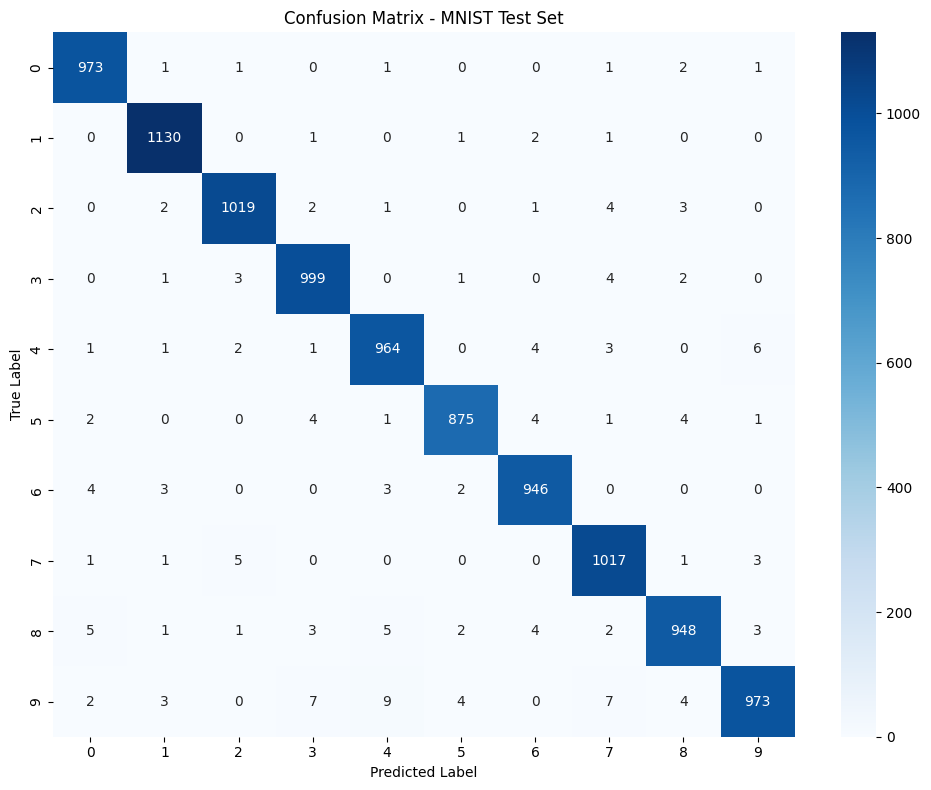

In [33]:
def plot_confusion_matrix(y_true, y_pred, classes=range(10)):
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes)
    plt.xlabel('Predicted Label')
    plt.ylabel('True Label')
    plt.title('Confusion Matrix - MNIST Test Set')
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(test_labels, test_preds)

Correct Predictions:


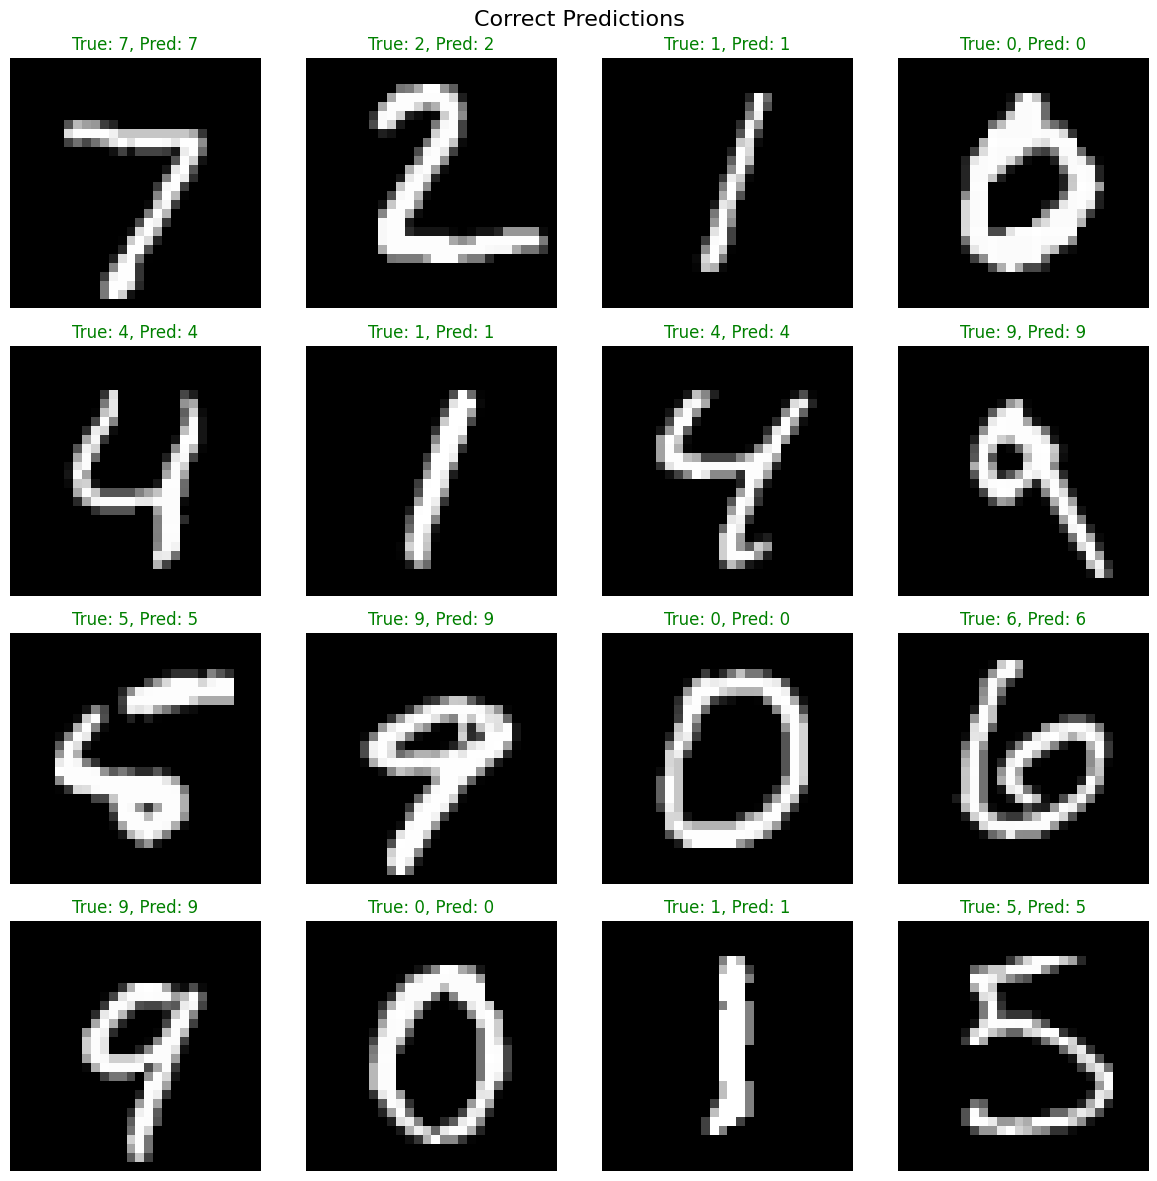

Incorrect Predictions:


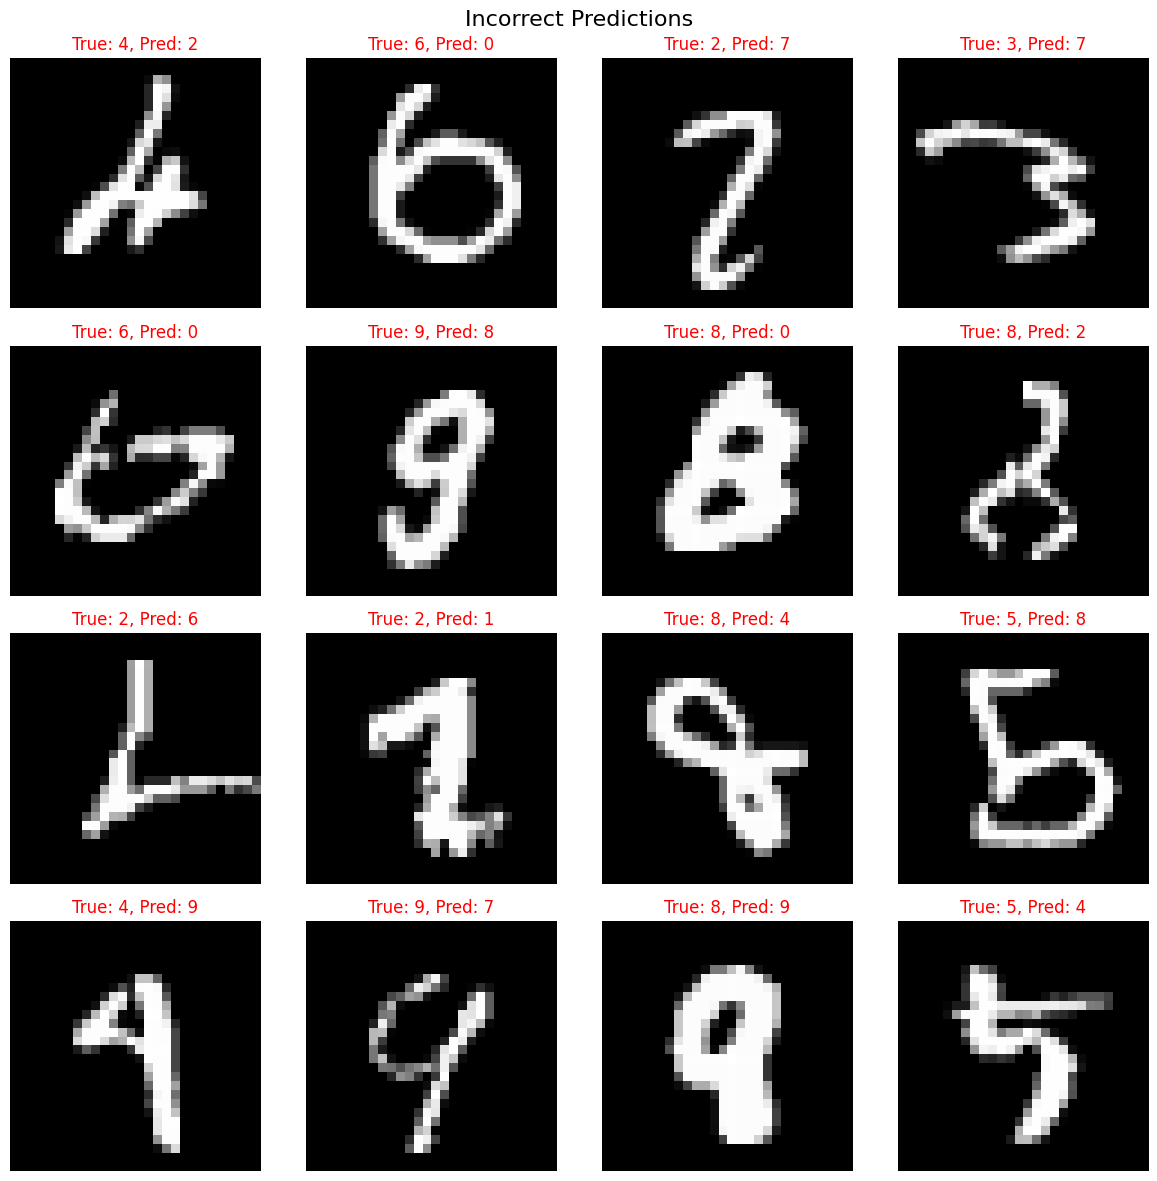

In [34]:
def visualize_predictions(loader, model, device, num_samples=16, correct=True):
    model.eval()
    
    images_shown = 0
    fig, axes = plt.subplots(4, 4, figsize=(12, 12))
    axes = axes.flatten()
    
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = outputs.max(1)
            
            mean, std = 0.1307, 0.3081
            images = images * std + mean
            
            for i in range(images.size(0)):
                is_correct = preds[i] == labels[i]
                if is_correct == correct and images_shown < num_samples:
                    ax = axes[images_shown]
                    ax.imshow(images[i].cpu().squeeze(), cmap='gray')
                    color = 'green' if is_correct else 'red'
                    ax.set_title(f'True: {labels[i].item()}, Pred: {preds[i].item()}', color=color)
                    ax.axis('off')
                    images_shown += 1
            
            if images_shown >= num_samples:
                break
    
    for i in range(images_shown, num_samples):
        axes[i].axis('off')
    
    title = 'Correct Predictions' if correct else 'Incorrect Predictions'
    fig.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

print("Correct Predictions:")
visualize_predictions(test_loader, model, device, correct=True)

print("Incorrect Predictions:")
visualize_predictions(test_loader, model, device, correct=False)

In [35]:
def run_experiment(hidden_sizes, activation='relu', dropout=0.2, lr=1e-3, epochs=15, name=None):
    if name is None:
        name = f"{activation}_{'-'.join(map(str, hidden_sizes))}_drop{dropout}"
    
    print(f"Experiment: {name}")
    
    model, criterion, optimizer, scheduler = create_model_and_optimizer(
        hidden_sizes=hidden_sizes,
        activation=activation,
        dropout=dropout,
        lr=lr
    )
    
    history = train_model(
        model, train_loader, val_loader,
        criterion, optimizer, scheduler,
        device, num_epochs=epochs, patience=4
    )
    
    test_loss, test_acc, _, _ = evaluate(model, test_loader, criterion, device)
    
    print(f"\nFinal Test Accuracy: {test_acc:.2f}%")
    
    return {
        'name': name,
        'model': model,
        'history': history,
        'test_acc': test_acc,
        'test_loss': test_loss,
        'params': model.get_num_parameters()
    }

In [36]:
# Define experiments to run
experiments = [
    # Baseline
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.2, 'name': 'Baseline (256-128, ReLU)'},
    
    # Different architectures
    {'hidden_sizes': [512, 256], 'activation': 'relu', 'dropout': 0.2, 'name': 'Larger (512-256, ReLU)'},
    {'hidden_sizes': [128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Smaller (128-64, ReLU)'},
    {'hidden_sizes': [256, 128, 64], 'activation': 'relu', 'dropout': 0.2, 'name': 'Deeper (256-128-64, ReLU)'},
    
    # Different activations
    {'hidden_sizes': [256, 128], 'activation': 'leaky_relu', 'dropout': 0.2, 'name': 'LeakyReLU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'gelu', 'dropout': 0.2, 'name': 'GELU (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'tanh', 'dropout': 0.2, 'name': 'Tanh (256-128)'},
    
    # Different dropout
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.0, 'name': 'No Dropout (256-128)'},
    {'hidden_sizes': [256, 128], 'activation': 'relu', 'dropout': 0.5, 'name': 'High Dropout (256-128)'},
]

In [37]:
results = []

for exp_config in experiments:
    result = run_experiment(
        hidden_sizes=exp_config['hidden_sizes'],
        activation=exp_config['activation'],
        dropout=exp_config['dropout'],
        name=exp_config['name'],
        epochs=10
    )
    results.append(result)

Experiment: Baseline (256-128, ReLU)


100%|██████████| 782/782 [00:07<00:00, 103.99it/s]


Epoch:    1 | Train Loss:    0.2981 | Train Acc:    90.92 | Val Loss:   0.1484 | Val Acc:   95.38 | Current LR:1.00e-03


100%|██████████| 782/782 [00:07<00:00, 101.01it/s]


Epoch:    2 | Train Loss:    0.1383 | Train Acc:    95.84 | Val Loss:   0.1186 | Val Acc:   96.62 | Current LR:1.00e-03


...

Epoch:    8 | Train Loss:    0.1456 | Train Acc:    95.68 | Val Loss:   0.1048 | Val Acc:   96.99 | Current LR:1.00e-03


100%|██████████| 782/782 [00:08<00:00, 97.67it/s] 


Epoch:    9 | Train Loss:    0.1427 | Train Acc:    95.81 | Val Loss:   0.0984 | Val Acc:   97.06 | Current LR:1.00e-03


100%|██████████| 782/782 [00:25<00:00, 31.12it/s] 


Epoch:   10 | Train Loss:    0.1336 | Train Acc:    96.04 | Val Loss:   0.1110 | Val Acc:   96.82 | Current LR:1.00e-03

Final Test Accuracy: 97.06%


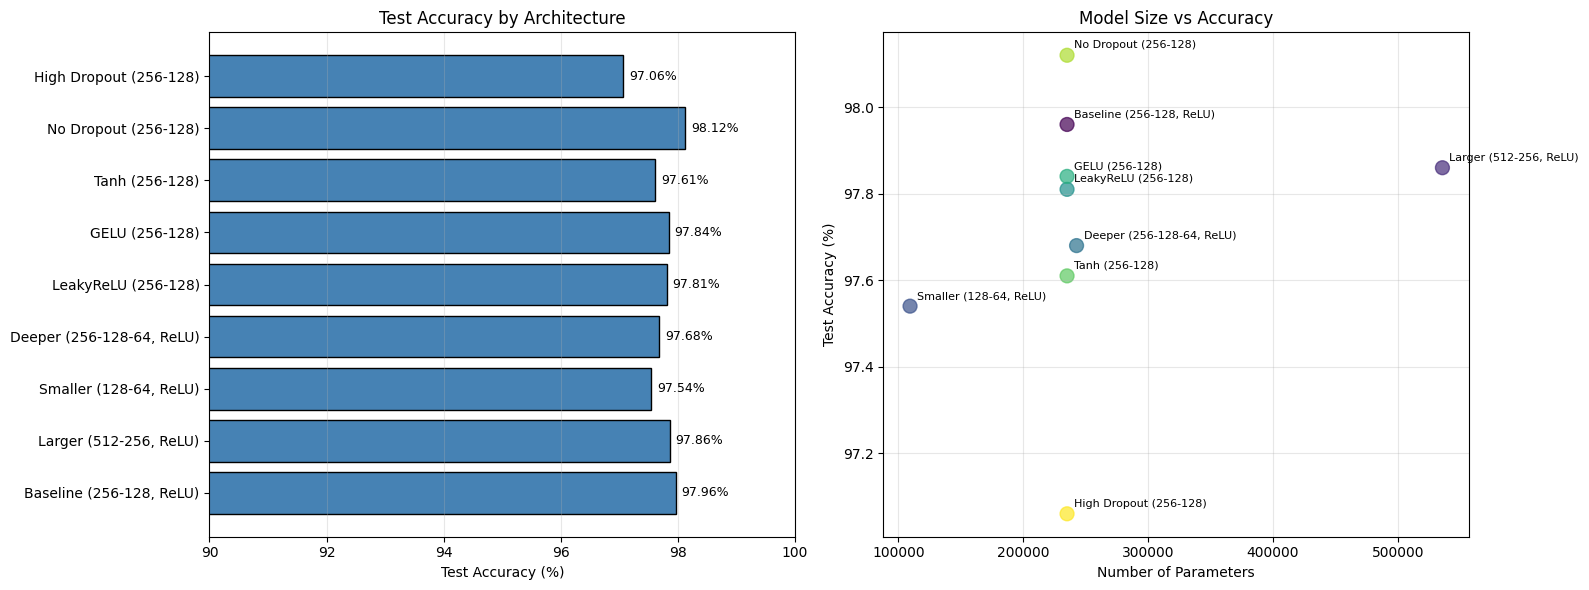

In [38]:
def plot_experiment_comparison(results):
    names = [r['name'] for r in results]
    test_accs = [r['test_acc'] for r in results]
    params = [r['params'] for r in results]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Test accuracy comparison
    bars = axes[0].barh(range(len(names)), test_accs, color='steelblue', edgecolor='black')
    axes[0].set_yticks(range(len(names)))
    axes[0].set_yticklabels(names)
    axes[0].set_xlabel('Test Accuracy (%)')
    axes[0].set_title('Test Accuracy by Architecture')
    axes[0].set_xlim(90, 100)
    axes[0].grid(True, alpha=0.3, axis='x')
    for i, (bar, acc) in enumerate(zip(bars, test_accs)):
        axes[0].text(acc + 0.1, bar.get_y() + bar.get_height()/2, 
                    f'{acc:.2f}%', va='center', fontsize=9)
    
    # Parameters vs Accuracy
    scatter = axes[1].scatter(params, test_accs, c=range(len(results)), cmap='viridis', s=100, alpha=0.7)
    for i, name in enumerate(names):
        axes[1].annotate(name, (params[i], test_accs[i]), 
                        xytext=(5, 5), textcoords='offset points', fontsize=8)
    axes[1].set_xlabel('Number of Parameters')
    axes[1].set_ylabel('Test Accuracy (%)')
    axes[1].set_title('Model Size vs Accuracy')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if results:
    plot_experiment_comparison(results)

In [39]:
# Print summary table
if results:
    print(f"{'Model':<35} {'Params':>10} {'Test Acc':>10} {'Test Loss':>10}")
    print("-" * 70)
    for r in sorted(results, key=lambda x: x['test_acc'], reverse=True):
        print(f"{r['name']:<35} {r['params']:>10,} {r['test_acc']:>10.2f}% {r['test_loss']:>10.4f}")

Model                                   Params   Test Acc  Test Loss
----------------------------------------------------------------------
No Dropout (256-128)                   235,146      98.12%     0.0701
Baseline (256-128, ReLU)               235,146      97.96%     0.0695
Larger (512-256, ReLU)                 535,818      97.86%     0.0776
GELU (256-128)                         235,146      97.84%     0.0728
LeakyReLU (256-128)                    235,146      97.81%     0.0782
Deeper (256-128-64, ReLU)              242,762      97.68%     0.0864
Tanh (256-128)                         235,146      97.61%     0.0824
Smaller (128-64, ReLU)                 109,386      97.54%     0.0836
High Dropout (256-128)                 235,146      97.06%     0.0948


In [42]:
# Find best model
if results:
    best_result = max(results, key=lambda x: x['test_acc'])
    best_model = best_result['model']
    
    save_path = 'best_mnist_mlp.pth'
    torch.save({
        'model_state_dict': best_model.state_dict(),
        'model_config': {
            'hidden_sizes': [256, 128],
            'activation': 'relu',
            'dropout': 0
        },
        'test_accuracy': best_result['test_acc'],
        'num_parameters': best_result['params']
    }, save_path)
    
    print(f"Best model saved to {save_path}")
    print(f"Best model: {best_result['name']}")
    print(f"Test Accuracy: {best_result['test_acc']:.2f}%")
    print(f"Parameters: {best_result['params']:,}")

Best model saved to best_mnist_mlp.pth
Best model: No Dropout (256-128)
Test Accuracy: 98.12%
Parameters: 235,146
